In [ ]:
!pip install -U --force-reinstall pyarrow pandas

  Using cached pyarrow-25.0.1-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
  Using cached pandas-3.0.5-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached numpy-2.5.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached pyarrow-25.0.1-cp313-cp313-manylinux_2_28_x86_64.whl (50.1 MB)
Using cached pandas-3.0.5-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
Using cached numpy-2.5.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall:

In [ ]:
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/imdb")
print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
from collections import Counter

print(Counter(dataset["train"]["label"]))
print(Counter(dataset["test"]["label"]))

Counter({0: 12500, 1: 12500})
Counter({0: 12500, 1: 12500})


In [ ]:
print("Negative Review:")
print(dataset["train"][0]["text"])
print("Label:", dataset["train"][0]["label"])

print("\nPositive Review:")
print(dataset["train"][12500]["text"])
print("Label:", dataset["train"][12500]["label"])

Negative Review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and

In [ ]:
train_texts = dataset["train"]["text"]

text_lengths = [len(text.split()) for text in train_texts]

print("Average words:", sum(text_lengths) / len(text_lengths))
print("Maximum words:", max(text_lengths))
print("Minimum words:", min(text_lengths))

Average words: 233.7872
Maximum words: 2470
Minimum words: 10


In [ ]:
print(dataset['train'].features)
print(dataset['train'].column_names)

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}
['text', 'label']


In [ ]:
train_val = dataset["train"].train_test_split(
    test_size=0.1,
    seed=42,
    stratify_by_column="label")

print(train_val)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 22500
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2500
    })
})


In [ ]:
train_dataset = train_val["train"]
val_dataset = train_val["test"]
test_dataset = dataset["test"]

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 22500
Validation: 2500
Test: 25000


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2)

print(model)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
sample_text = dataset["train"][0]["text"]
tokens = tokenizer(sample_text)

print(tokens)
print(tokenizer.tokenize(sample_text))
print(tokenizer.convert_tokens_to_ids(tokenizer.tokenize(sample_text)))

{'input_ids': [101, 1045, 12524, 1045, 2572, 8025, 1011, 3756, 2013, 2026, 2678, 3573, 2138, 1997, 2035, 1996, 6704, 2008, 5129, 2009, 2043, 2009, 2001, 2034, 2207, 1999, 3476, 1012, 1045, 2036, 2657, 2008, 2012, 2034, 2009, 2001, 8243, 2011, 1057, 1012, 1055, 1012, 8205, 2065, 2009, 2412, 2699, 2000, 4607, 2023, 2406, 1010, 3568, 2108, 1037, 5470, 1997, 3152, 2641, 1000, 6801, 1000, 1045, 2428, 2018, 2000, 2156, 2023, 2005, 2870, 1012, 1026, 7987, 1013, 1028, 1026, 7987, 1013, 1028, 1996, 5436, 2003, 8857, 2105, 1037, 2402, 4467, 3689, 3076, 2315, 14229, 2040, 4122, 2000, 4553, 2673, 2016, 2064, 2055, 2166, 1012, 1999, 3327, 2016, 4122, 2000, 3579, 2014, 3086, 2015, 2000, 2437, 2070, 4066, 1997, 4516, 2006, 2054, 1996, 2779, 25430, 14728, 2245, 2055, 3056, 2576, 3314, 2107, 2004, 1996, 5148, 2162, 1998, 2679, 3314, 1999, 1996, 2142, 2163, 1012, 1999, 2090, 4851, 8801, 1998, 6623, 7939, 4697, 3619, 1997, 8947, 2055, 2037, 10740, 2006, 4331, 1010, 2016, 2038, 3348, 2007, 2014, 3689, 383

In [ ]:
token_lengths = [
    len(tokenizer(text)["input_ids"])
    for text in dataset["train"]["text"]
]

print("Average tokens:", sum(token_lengths) / len(token_lengths))
print("Maximum tokens:", max(token_lengths))
print("Minimum tokens:", min(token_lengths))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (720 > 512). Running this sequence through the model will result in indexing errors


Average tokens: 313.87132
Maximum tokens: 3127
Minimum tokens: 13


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
tokenized_datasets = train_val.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_datasets)
print(tokenized_test)
print(tokenized_datasets["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 22500
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2500
    })
})
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 25000
})
{'text': 'Every generation fully believes it is living in the end times. This has been true for thousands of years now. And movies like this feed on this. How did they get the great Orson Welles to narrate this train wreck? This is a documentary about the biblical prophecies of Armageddon. It tries to link the prophecies as well as it can to what was happening in the times it was made, making it obviously dated and kind of silly.<br /><br />The reenactments look like they are out of "Unsolved Mysteries" but without the high production values. People should have been embarrassed to take p

In [ ]:
sample = tokenized_datasets["train"][0]

print("Label:", sample["label"])
print("Number of input_ids:", len(sample["input_ids"]))
print("Number of attention_mask:", len(sample["attention_mask"]))
print("First 20 input_ids:", sample["input_ids"][:20])
print("First 20 attention_mask:", sample["attention_mask"][:20])

Label: 0
Number of input_ids: 256
Number of attention_mask: 256
First 20 input_ids: [101, 2296, 4245, 3929, 7164, 2009, 2003, 2542, 1999, 1996, 2203, 2335, 1012, 2023, 2038, 2042, 2995, 2005, 5190, 1997]
First 20 attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.245030,0.247678,0.904400,0.916049,0.890400,0.903043
2,0.198363,0.287998,0.910000,0.917006,0.901600,0.909238


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2814, training_loss=0.2353825947030182, metrics={'train_runtime': 1017.8636, 'train_samples_per_second': 44.21, 'train_steps_per_second': 2.765, 'total_flos': 2980516469760000.0, 'train_loss': 0.2353825947030182, 'epoch': 2.0})

In [ ]:
test_results = trainer.evaluate(tokenized_test)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.198363,0.272902,2,0.913720,0.914151,0.913200,0.913675


{'eval_loss': 0.27290230989456177, 'eval_accuracy': 0.91372, 'eval_precision': 0.9141507167454153, 'eval_recall': 0.9132, 'eval_f1': 0.91367511105775}


In [ ]:
predictions = trainer.predict(tokenized_test)

logits = predictions.predictions
true_labels = predictions.label_ids
predicted_labels = np.argmax(logits, axis=-1)

print("Logits shape:", logits.shape)
print("True labels shape:", true_labels.shape)
print("Predicted labels shape:", predicted_labels.shape)

Logits shape: (25000, 2)
True labels shape: (25000,)
Predicted labels shape: (25000,)


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)
print(cm)

[[11428  1072]
 [ 1085 11415]]


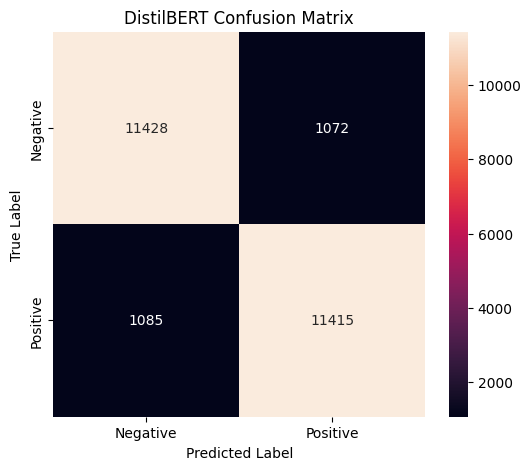

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DistilBERT Confusion Matrix")
plt.show()

In [ ]:
misclassified_indices = np.where(
    true_labels != predicted_labels
)[0]

print("Total misclassified:", len(misclassified_indices))
print("First 10 indices:", misclassified_indices[:10])

Total misclassified: 2157
First 10 indices: [ 4 18 20 37 46 61 73 74 86 87]


In [ ]:
for idx in misclassified_indices[:10]:
    print("=" * 100)
    print("Index:", idx)
    print("Actual:", true_labels[idx])
    print("Predicted:", predicted_labels[idx])
    print('Word count:', len(dataset["test"][idx]["text"].split()))
    print("Review:", dataset["test"][idx]["text"])

Index: 4
Actual: 0
Predicted: 1
Word count: 134
Review: First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!
Index: 18
Actual: 0
Predicted: 1
Word count: 249
Review: Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney), is ... well, let's just say she's a somewhat

In [ ]:
X_train = train_dataset["text"]
y_train = train_dataset["label"]

X_test = test_dataset["text"]
y_test = test_dataset["label"]

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 22500
Test samples: 25000


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (22500, 50000)
Test TF-IDF shape: (25000, 50000)


In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000
)

baseline_model.fit(X_train_tfidf, y_train)
baseline_predictions = baseline_model.predict(X_test_tfidf)


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

baseline_precision, baseline_recall, baseline_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        baseline_predictions,
        average="binary"
    )
)

print("TF-IDF + Logistic Regression")
print("Accuracy :", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1       :", baseline_f1)

TF-IDF + Logistic Regression
Accuracy : 0.89244
Precision: 0.8896036851719482
Recall   : 0.89608
F1       : 0.8928300984416723


In [1]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
save_path = "/content/drive/MyDrive/distilbert_imdb"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model and tokenizer saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully!


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

save_path = "/content/drive/MyDrive/distilbert_imdb"

tokenizer = AutoTokenizer.from_pretrained(save_path)

model = AutoModelForSequenceClassification.from_pretrained(save_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Model loaded successfully!")
print("Device:", device)

Loading weights:   0%|          | 0/104 [00:02<?, ?it/s]

Model loaded successfully!
Device: cuda


In [4]:
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0][predicted_class].item()

    label = "Positive" if predicted_class == 1 else "Negative"

    return label, confidence

In [5]:
text = "This movie was absolutely amazing. I loved every minute of it."

label, confidence = predict_sentiment(text)

print("Prediction:", label)
print("Confidence:", f"{confidence:.2%}")

Prediction: Positive
Confidence: 99.59%


In [6]:
text = "This movie was boring, poorly written, and a complete waste of time."

label, confidence = predict_sentiment(text)

print("Prediction:", label)
print("Confidence:", f"{confidence:.2%}")

Prediction: Negative
Confidence: 99.62%


In [7]:
!pip install -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 18.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0


In [8]:
from huggingface_hub import notebook_login

notebook_login()

In [9]:
from huggingface_hub import HfApi

api = HfApi()

api.create_repo(
    repo_id="Oblivion22/distilbert-imdb-sentiment",
    repo_type="model",
    exist_ok=True
)

print("Repository created!")

Repository created!


In [10]:
model.push_to_hub("Oblivion22/distilbert-imdb-sentiment")
tokenizer.push_to_hub("Oblivion22/distilbert-imdb-sentiment")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...1wyo59k/model.safetensors:   2%|2         | 5.55MB /  268MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Oblivion22/distilbert-imdb-sentiment/commit/7cfe6bc768df99b963c1ab33e535cf74d37cb3ed', commit_message='Upload tokenizer', commit_description='', oid='7cfe6bc768df99b963c1ab33e535cf74d37cb3ed', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Oblivion22/distilbert-imdb-sentiment', endpoint='https://huggingface.co', repo_type='model', repo_id='Oblivion22/distilbert-imdb-sentiment'), pr_revision=None, pr_num=None)

# New Section

In [13]:
%%writefile app.py

import streamlit as st
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "Oblivion22/distilbert-imdb-sentiment"

@st.cache_resource
def load_model():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
    model.eval()
    return tokenizer, model

tokenizer, model = load_model()

st.title("IMDB Sentiment Classifier")
st.write("Fine-tuned DistilBERT for movie review sentiment classification.")

text = st.text_area(
    "Enter a movie review:",
    placeholder="Example: This movie was absolutely amazing!"
)

if st.button("Predict"):
    if not text.strip():
        st.warning("Please enter a review.")
    else:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        )

        with torch.no_grad():
            outputs = model(**inputs)

        probabilities = torch.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(probabilities, dim=-1).item()
        confidence = probabilities[0][predicted_class].item()

        label = "Positive" if predicted_class == 1 else "Negative"

        st.subheader(f"Prediction: {label}")
        st.write(f"Confidence: {confidence:.2%}")

Overwriting app.py


In [14]:
%%writefile requirements.txt

streamlit
torch
transformers

Overwriting requirements.txt
